# Лабораторная №6

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set(style="whitegrid")

In [3]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv("diabetes.csv", names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


## Предобработка данных
В колонках `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` значения 0 невозможны и являются пропусками, поэтому заменим их на NaN и удалим эти строки

In [7]:
features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[features_with_zeros] = df[features_with_zeros].replace(0, np.nan)

print("Количество пропусков до удаления:")
print(df.isna().sum())

df_clean = df.dropna().copy()

for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna()

print(f"\nРазмер датасета до очистки: {df.shape}")
print(f"Размер датасета после очистки: {df_clean.shape}")

Количество пропусков до удаления:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Размер датасета до очистки: (769, 9)
Размер датасета после очистки: (768, 9)


## Статистический анализ и визуализация
Получим основные метрики и построим гистограммы распределения

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


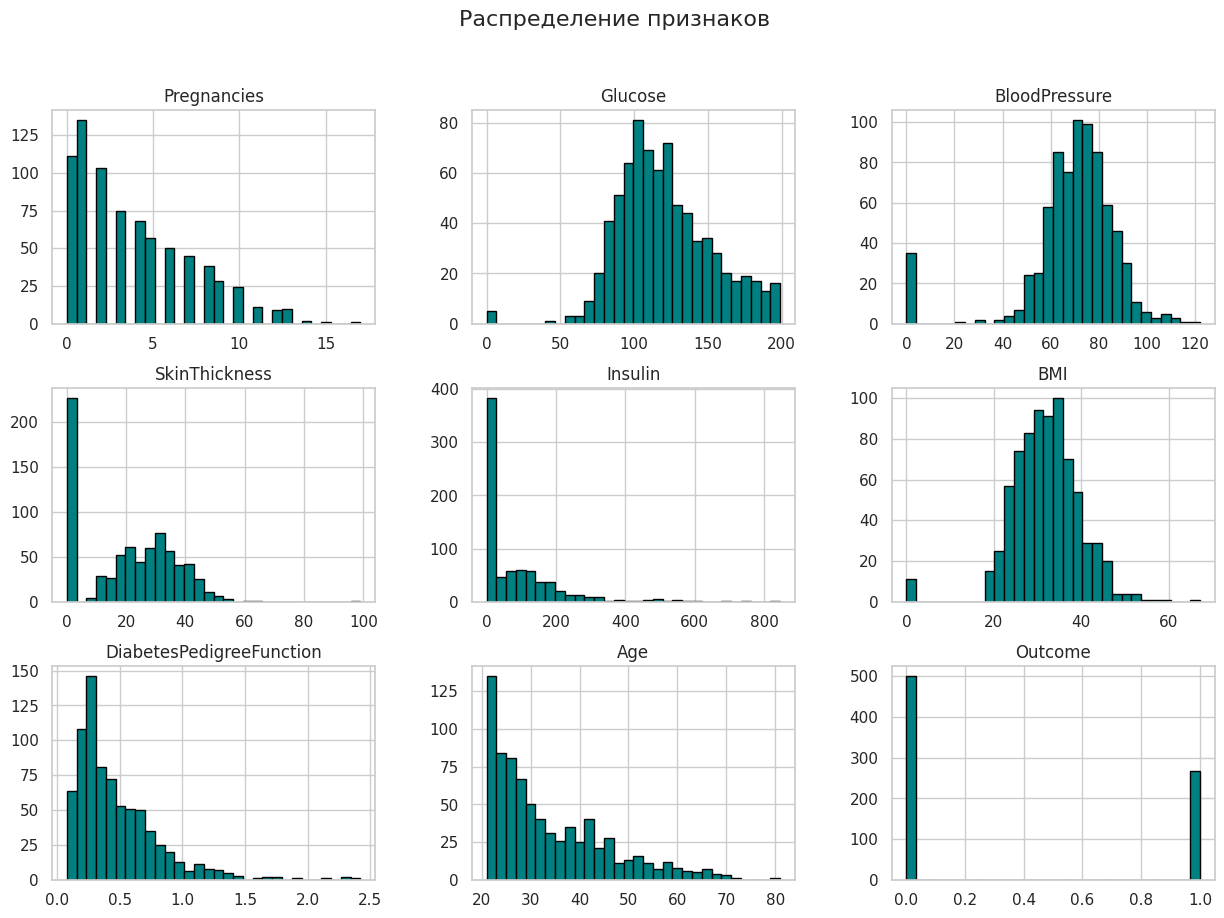

In [8]:
display(df_clean.describe())

df_clean.hist(bins=30, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Распределение признаков', fontsize=16)
plt.show()

### Анализ выбросов и корреляции

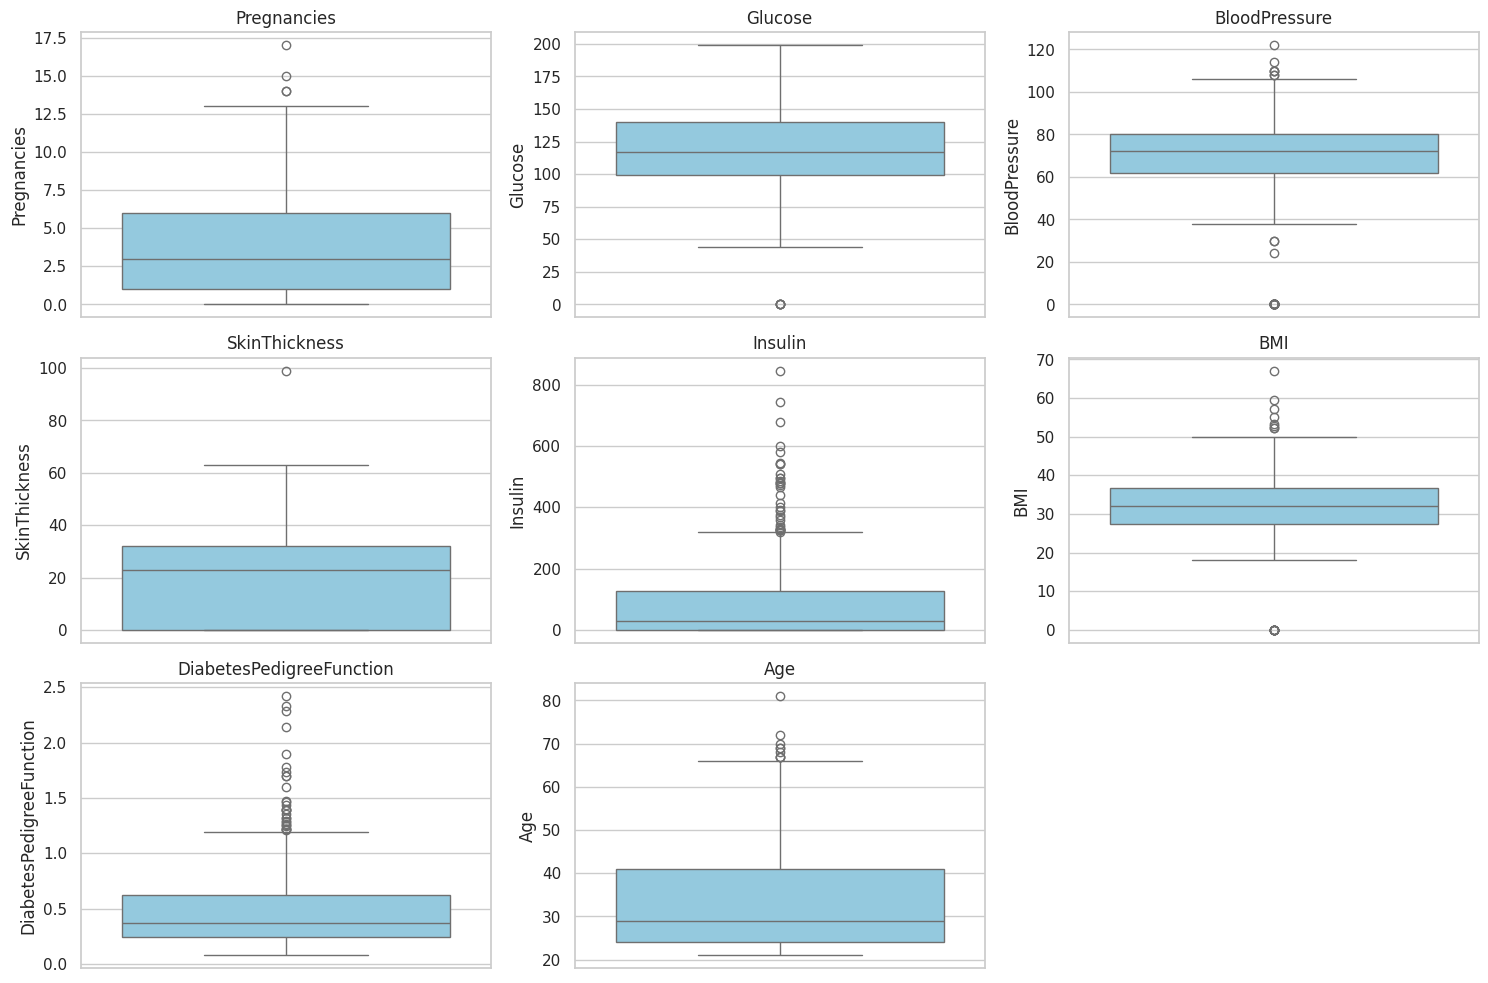

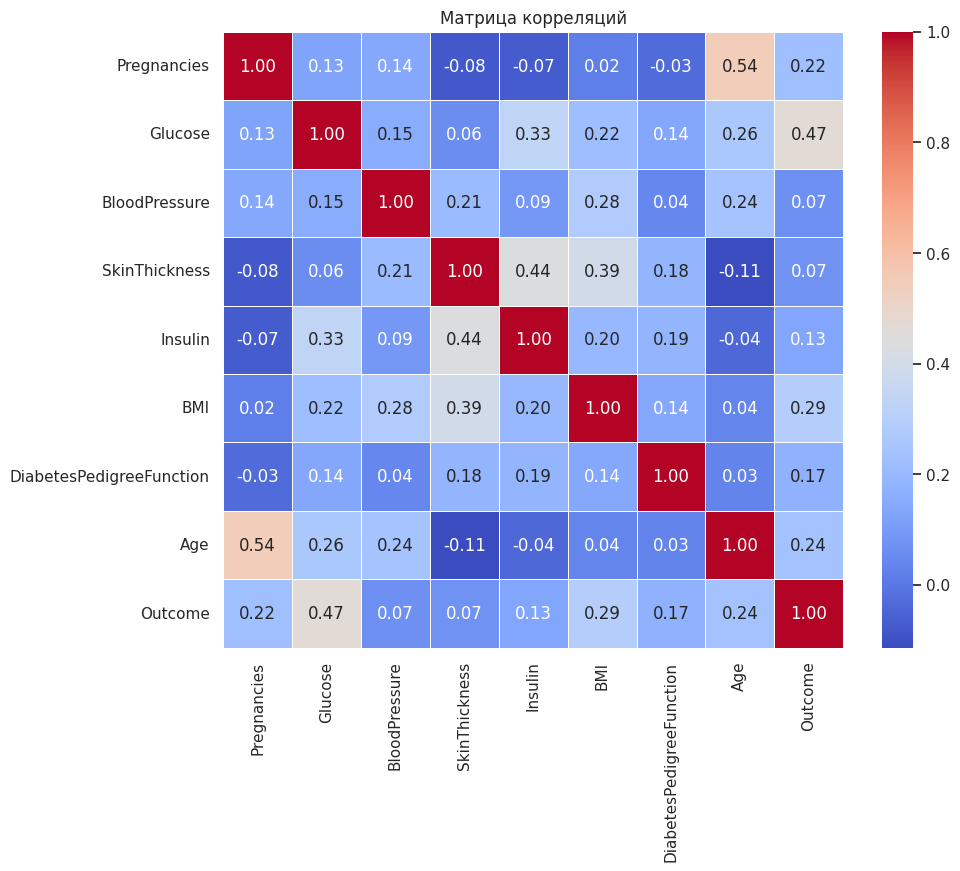

In [9]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_clean.columns[:-1]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_clean[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляций')
plt.show()

### Нормализация данных

In [10]:
def min_max_scaler(data):
    normalized_data = data.copy()
    for column in data.columns:
        if column != 'Outcome':
            min_val = data[column].min()
            max_val = data[column].max()
            normalized_data[column] = (data[column] - min_val) / (max_val - min_val)
    return normalized_data

df_norm = min_max_scaler(df_clean)
df_norm.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,0.352941,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,0.483333,1.0
2,0.058824,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,0.166667,0.0
3,0.470588,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,0.183333,1.0
4,0.058824,0.447236,0.540984,0.232323,0.111111,0.418778,0.038002,0.000000,0.0
5,0.000000,0.688442,0.327869,0.353535,0.198582,0.642325,0.943638,0.200000,1.0


### Train/test split

In [11]:
def custom_train_test_split(data, target_col, test_size=0.2, random_seed=42):
    np.random.seed(random_seed)
    
    indices = np.arange(len(data))
    np.random.shuffle(indices)
    
    split_idx = int(len(data) * (1 - test_size))
    
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    train_data = data.iloc[train_indices]
    test_data = data.iloc[test_indices]
    
    X_train = train_data.drop(columns=[target_col]).values
    y_train = train_data[target_col].values
    
    X_test = test_data.drop(columns=[target_col]).values
    y_test = test_data[target_col].values
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = custom_train_test_split(df_norm, 'Outcome', test_size=0.25)
print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")

Обучающая выборка: (576, 8), Тестовая выборка: (192, 8)


### Реализация логистической регрессии

In [12]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, method='gradient_descent'):
        self.lr = learning_rate
        self.num_iterations = num_iterations
        self.method = method
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.cost_history = []

        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            cost = self._compute_loss(y, y_pred)
            self.cost_history.append(cost)

            if self.method == 'gradient_descent':
                dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
                db = (1 / n_samples) * np.sum(y_pred - y)
                
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            elif self.method == 'newton':
                grad_w = (1 / n_samples) * np.dot(X.T, (y_pred - y))
                grad_b = (1 / n_samples) * np.sum(y_pred - y)
                
                S = np.diag(y_pred * (1 - y_pred))
                
                H = (1 / n_samples) * np.dot(X.T, np.dot(S, X)) + 1e-5 * np.eye(n_features)
                
                try:
                    H_inv = np.linalg.inv(H)
                    self.weights -= np.dot(H_inv, grad_w)
                    self.bias -= self.lr * grad_b 
                except np.linalg.LinAlgError:
                    self.weights -= self.lr * grad_w
                    self.bias -= self.lr * grad_b

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_pred]

### Функции метрик

In [13]:
def get_metrics(y_true, y_pred):
    tp = np.sum((np.array(y_true) == 1) & (np.array(y_pred) == 1))
    tn = np.sum((np.array(y_true) == 0) & (np.array(y_pred) == 0))
    fp = np.sum((np.array(y_true) == 0) & (np.array(y_pred) == 1))
    fn = np.sum((np.array(y_true) == 1) & (np.array(y_pred) == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1

### Исследование гиперпараметров (Grid search)
Проведем эксперименты с разным learning rate, количеством итераций и двумя методами оптимизации

In [14]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
iterations_list = [100, 500, 1000]
methods = ['gradient_descent', 'newton']

results = []

print(f"{'Method':<20} | {'LR':<5} | {'Iters':<5} | {'Acc':<5} | {'Prec':<5} | {'Rec':<5} | {'F1':<5}")
print("-" * 75)

best_model = None
best_f1 = 0
best_params = {}

for method in methods:
    for lr in learning_rates:
        for iters in iterations_list:
            if method == 'newton' and lr != 0.1: continue
            
            model = LogisticRegression(learning_rate=lr, num_iterations=iters, method=method)
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)
            
            acc, prec, rec, f1 = get_metrics(y_test, predictions)
            
            results.append({
                'method': method,
                'lr': lr,
                'iters': iters,
                'accuracy': acc,
                'f1': f1,
                'loss_history': model.cost_history
            })
            
            print(f"{method:<20} | {lr:<5} | {iters:<5} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_model = model
                best_params = {'method': method, 'lr': lr, 'iters': iters}

print("\nЛучшие параметры:", best_params)

Method               | LR    | Iters | Acc   | Prec  | Rec   | F1   
---------------------------------------------------------------------------
gradient_descent     | 0.001 | 100   | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.001 | 500   | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.001 | 1000  | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.01  | 100   | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.01  | 500   | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.01  | 1000  | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.1   | 100   | 0.641 | 0.000 | 0.000 | 0.000
gradient_descent     | 0.1   | 500   | 0.661 | 0.700 | 0.101 | 0.177
gradient_descent     | 0.1   | 1000  | 0.703 | 0.773 | 0.246 | 0.374
gradient_descent     | 1.0   | 100   | 0.703 | 0.773 | 0.246 | 0.374
gradient_descent     | 1.0   | 500   | 0.740 | 0.711 | 0.464 | 0.561
gradient_descent     | 1.0   | 1000  | 0.740 | 0.686 | 0.507 | 0.583
newton               | 0.1 

### Визуализация обучения лучших моделей
Сравним графики падения функции потерь (loss) для разных подходов

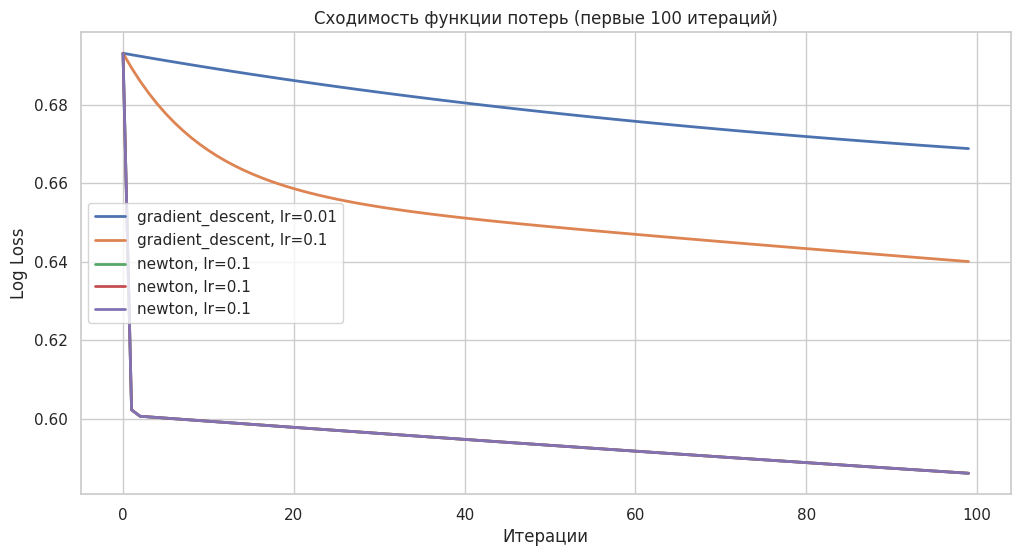

In [15]:
plt.figure(figsize=(12, 6))

experiments_to_plot = [
    (res) for res in results 
    if (res['method'] == 'gradient_descent' and res['lr'] == 0.1 and res['iters'] == 1000) or
       (res['method'] == 'gradient_descent' and res['lr'] == 0.01 and res['iters'] == 1000) or
       (res['method'] == 'newton')
]

for exp in experiments_to_plot:
    label = f"{exp['method']}, lr={exp['lr']}"
    plt.plot(exp['loss_history'][:100], label=label, linewidth=2)

plt.xlabel('Итерации')
plt.ylabel('Log Loss')
plt.title('Сходимость функции потерь (первые 100 итераций)')
plt.legend()
plt.show()

## Выводы
1. Влияние Learning Rate (для GD):
 - При слишком низком LR (0.001) модель обучается очень медленно, и 1000 итераций недостаточно для достижения минимума функции потерь.
 - При LR = 0.1 или 1.0 сходимость происходит гораздо быстрее. Accuracy и F1-score значительно выше.
2. Количество итераций:
 - Увеличение количества итераций положительно сказывается на метриках при малом LR.
 - Для большого LR модель быстро выходит на плато, и дальнейшее увеличение итераций не дает прироста качества.
3. Метод оптимизации:
 - Метод Ньютона показал экстремально быструю сходимость (буквально за 5-10 итераций функция потерь упала до минимума). Это связано с использованием информации о кривизне функции (вторая производная/Гессиан).
 - Однако метод Ньютона вычислительно дороже на каждой итерации из-за необходимости обращать матрицу Гессиана.
4. Лучшая модель:
 - На данном датасете наилучшие результаты (F1 ~ 0.7-0.8) показали как Градиентный спуск с высоким LR, так и метод Ньютона. Выбор зависит от доступных вычислительных ресурсов.